## 📊 RQ4 Analysis

How does the percentage of apps classified as obfuscated change across manual thresholds?

In [11]:
# Imports
from   prettytable          import PrettyTable
from   dotenv          		import load_dotenv
from   matplotlib      		import colors as mcolors
from   pathlib              import Path
import matplotlib.pyplot 	as plt
import pandas          		as pd
import datetime
import json
import os

##### Initialization

In [12]:
print("⚡ START: {} ⚡".format(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")))
initTime = datetime.datetime.now()

⚡ START: 2026-06-01 12:15:35 ⚡


In [13]:
# Load .env Info
load_dotenv()

True

#### 📥 1] Load Data

Parameters

In [ ]:
# Full configuration prepared for future completed runs, following the RQ1/RQ2 notebooks.
MODELS 		= ["gpt-4o-mini", "gpt-5-mini", "deepseek-r1_32b", "gemma3_27b", "qwen3_30b", "gpt-oss_20b"]
PROMPTS 	= ["ObfuscationDetectionV1", "ObfuscationDetectionV2", "ObfuscationDetectionV3"]
THRESHOLDS 	= [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Only this completed run is loaded for the moment.
ACTIVE_MODELS  = ["gpt-4o-mini"]
ACTIVE_PROMPTS = ["ObfuscationDetectionV3"]

RESULTS_PATH = Path("Results")
MANUAL_ANALYSIS_PATH = RESULTS_PATH / "manualAnalysis"
MANUAL_ANALYSIS_PATH.mkdir(parents = True, exist_ok = True)

Helpers

In [15]:
def sanitizeFilenamePart(value):
	return str(value).replace(":", "_").replace("/", "_").replace(" ", "_")

def buildResultsFilePaths(resultsPath, promptId, modelName):
	basePath = resultsPath / promptId
	csvPath = basePath / "results_{}.csv".format(modelName)
	jsonPath = basePath / "results_{}.json".format(modelName)
	return csvPath, jsonPath

def loadResults(resultsPath, promptId, modelName):
	csvPath, jsonPath = buildResultsFilePaths(resultsPath, promptId, modelName)
	if csvPath.exists():
		print("--- 📄 Loading CSV  : {}".format(csvPath))
		resultsDf = pd.read_csv(csvPath)
	elif jsonPath.exists():
		print("--- 📄 Loading JSON : {}".format(jsonPath))
		with open(jsonPath, "r") as inputFile:
			resultsDf = pd.DataFrame(json.load(inputFile))
	else:
		return None

	resultsDf = resultsDf[resultsDf["status"] == "SUCCESS"].copy()
	resultsDf["pctObfuscated"] = pd.to_numeric(resultsDf["pctSmaliClassesObfuscated"])
	resultsDf["model"] = modelName
	resultsDf["prompt"] = promptId
	return resultsDf

def buildThresholdFilename(promptId, modelName, threshold):
	return "apps_{}_{}_threshold_{:.1f}.csv".format(
		sanitizeFilenamePart(promptId),
		sanitizeFilenamePart(modelName),
		threshold
	)

Loading Data

In [16]:
resultsDfList = []
skippedRuns = []

for modelName in ACTIVE_MODELS:
	for promptId in ACTIVE_PROMPTS:
		print("\n--- 🔍 Checking Combination : model={} | prompt={}".format(modelName, promptId))
		resultsDf = loadResults(RESULTS_PATH, promptId, modelName)
		if resultsDf is None:
			print("--- ⚠️ Skipping missing result file")
			skippedRuns.append({"model": modelName, "prompt": promptId})
			continue
		print("--- 📦 Loaded Apps : {}".format(len(resultsDf)))
		resultsDfList.append(resultsDf)

if len(resultsDfList) == 0:
	raise ValueError("No completed RQ4 result files were found.")

resultsDf = pd.concat(resultsDfList, ignore_index = True)
skippedRunsDf = pd.DataFrame(skippedRuns)


--- 🔍 Checking Combination : model=gpt-4o-mini | prompt=ObfuscationDetectionV3
--- 📄 Loading CSV  : Results/ObfuscationDetectionV3/results_gpt-4o-mini.csv
--- 📦 Loaded Apps : 100


#### 📋 2] Pretty Threshold Table

In [17]:
summaryRows = []
totalApps = len(resultsDf)

for threshold in THRESHOLDS:
	numObfuscated = int((resultsDf["pctObfuscated"] >= threshold).sum())
	summaryRows.append({
		"threshold": threshold,
		"pctObfuscated": numObfuscated / totalApps,
		"pctNotObfuscated": (totalApps - numObfuscated) / totalApps,
	})

thresholdSummaryDf = pd.DataFrame(summaryRows)
thresholdSummaryCsvPath = RESULTS_PATH / "threshold_summary.csv"
thresholdSummaryDf.to_csv(thresholdSummaryCsvPath, index = False)

prettyThresholdTable = PrettyTable()
prettyThresholdTable.field_names = ["Threshold", "pctObfuscated", "pctNotObfuscated"]
for _, row in thresholdSummaryDf.iterrows():
	prettyThresholdTable.add_row([
		"{:.1f}".format(row["threshold"]),
		"{:.2%}".format(row["pctObfuscated"]),
		"{:.2%}".format(row["pctNotObfuscated"]),
	])

print(prettyThresholdTable)
print("\n--- 💾 Threshold summary saved : {}".format(thresholdSummaryCsvPath))

+-----------+---------------+------------------+
| Threshold | pctObfuscated | pctNotObfuscated |
+-----------+---------------+------------------+
|    0.1    |     72.00%    |      28.00%      |
|    0.2    |     63.00%    |      37.00%      |
|    0.3    |     58.00%    |      42.00%      |
|    0.4    |     54.00%    |      46.00%      |
|    0.5    |     51.00%    |      49.00%      |
|    0.6    |     46.00%    |      54.00%      |
|    0.7    |     40.00%    |      60.00%      |
|    0.8    |     37.00%    |      63.00%      |
|    0.9    |     28.00%    |      72.00%      |
+-----------+---------------+------------------+

--- 💾 Threshold summary saved : Results/manual Analysis/threshold_summary.csv


#### 📈 3] Stacked Bar Plot

--- 💾 Plot saved : Results/manual Analysis/threshold_distribution_ObfuscationDetectionV3_gpt-4o-mini.png


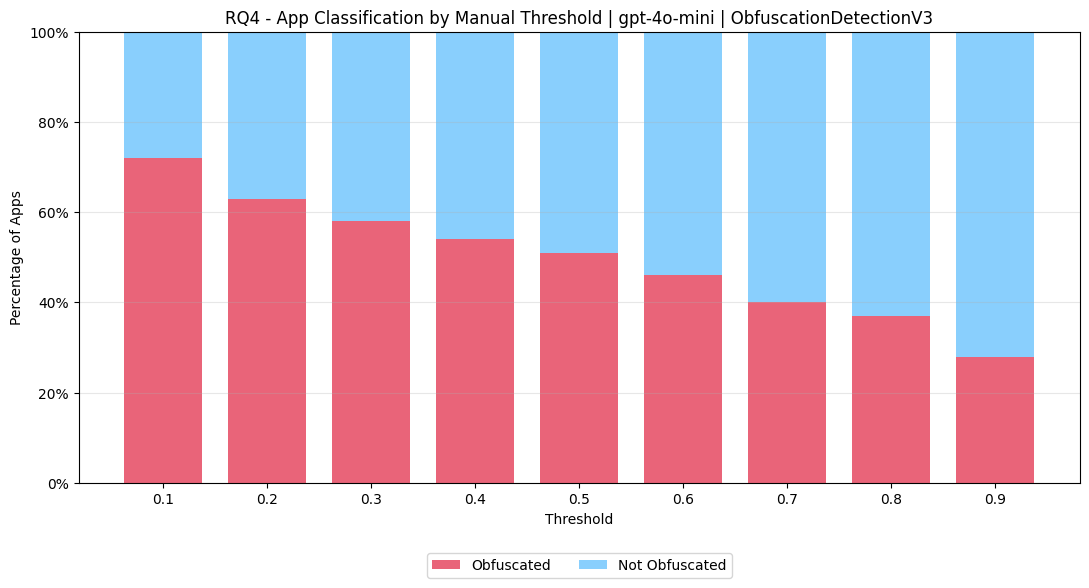

In [18]:
fig, ax = plt.subplots(figsize = (11, 6))
ax.bar(thresholdSummaryDf["threshold"], thresholdSummaryDf["pctObfuscated"], width = 0.075, color = "#E96479", label = "Obfuscated")
ax.bar(thresholdSummaryDf["threshold"], thresholdSummaryDf["pctNotObfuscated"], width = 0.075, bottom = thresholdSummaryDf["pctObfuscated"], color = "#89CFFD", label = "Not Obfuscated")
ax.set_title("RQ4 - App Classification by Manual Threshold | {} | {}".format(ACTIVE_MODELS[0], ACTIVE_PROMPTS[0]))
ax.set_xlabel("Threshold")
ax.set_ylabel("Percentage of Apps")
ax.set_xticks(THRESHOLDS)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax = 1))
ax.grid(axis = "y", alpha = 0.3)
ax.legend(loc = "upper center", bbox_to_anchor = (0.5, -0.14), ncol = 2)
plt.tight_layout()

plotPath = RESULTS_PATH / "threshold_distribution_{}_{}.png".format(sanitizeFilenamePart(ACTIVE_PROMPTS[0]), sanitizeFilenamePart(ACTIVE_MODELS[0]))
plt.savefig(plotPath, bbox_inches = "tight", dpi = 300)
print("--- 💾 Plot saved : {}".format(plotPath))
plt.show()

#### 💾 4] Save One App List CSV per Threshold

In [19]:
exportedCsvPaths = []
exportColumns = ["sha256", "pkgName", "pctObfuscated", "isObfuscated"]

for modelName in ACTIVE_MODELS:
	for promptId in ACTIVE_PROMPTS:
		runDf = resultsDf[(resultsDf["model"] == modelName) & (resultsDf["prompt"] == promptId)].copy()
		if runDf.empty:
			continue

		for threshold in THRESHOLDS:
			exportDf = runDf[["sha256", "pkgName", "pctObfuscated"]].copy()
			exportDf["isObfuscated"] = exportDf["pctObfuscated"] >= threshold
			exportPath = MANUAL_ANALYSIS_PATH / buildThresholdFilename(promptId, modelName, threshold)
			exportDf[exportColumns].to_csv(exportPath, index = False)
			exportedCsvPaths.append(exportPath)
			print("--- 💾 CSV saved : {}".format(exportPath))

print("\n--- ✅ Exported CSV files : {}".format(len(exportedCsvPaths)))

--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.1.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.2.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.3.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.4.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.5.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.6.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.7.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.8.csv
--- 💾 CSV saved : Results/manual Analysis/apps_ObfuscationDetectionV3_gpt-4o-mini_threshold_0.9.csv

--- ✅ Exported CSV files : 9


##### 🔚 End

In [20]:
endTime = datetime.datetime.now()
print("\n🔚 --- END:  {} --- 🔚".format(endTime.strftime("%Y-%m-%d %H:%M:%S")))

totalTime = endTime - initTime
hours = totalTime.total_seconds() // 3600
minutes = (totalTime.total_seconds() % 3600) // 60
print("⏱️ --- Time: {:02d} hours and {:02d} minutes [{:02d} seconds] --- ⏱️".format(int(hours), int(minutes), int(totalTime.total_seconds())))


🔚 --- END:  2026-06-01 12:15:36 --- 🔚
⏱️ --- Time: 00 hours and 00 minutes [01 seconds] --- ⏱️
